Youtube 강의 07.선형회귀 부터 총정리


회귀분석->loss 함수로는 Mse  Linear
분류분석,1: 이분류는 BCE    Sigmoid
         2: 세분류이상은 CE  Softmax

In [ ]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!pip install torchviz

In [ ]:
# 기본 폰트 설정
# plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

Youtube06강 강의 시작

In [ ]:
#Gradient descent 경사 하강법
sampleData1=np.array(
    [[166, 58.7],
    [176, 75.7],
    [171, 62.1],
    [173,74.4],
    [169,60.1]])

print('sampleData1=\n',sampleData1)

x=sampleData1[:,0]#height #166,176,171,173,169
y=sampleData1[:,1]#weight #58.7,75.7,62.1,74.4,60.1

sampleData1=
 [[166.   58.7]
 [176.   75.7]
 [171.   62.1]
 [173.   74.4]
 [169.   60.1]]


<ipython-input-21-3229aae8db67>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


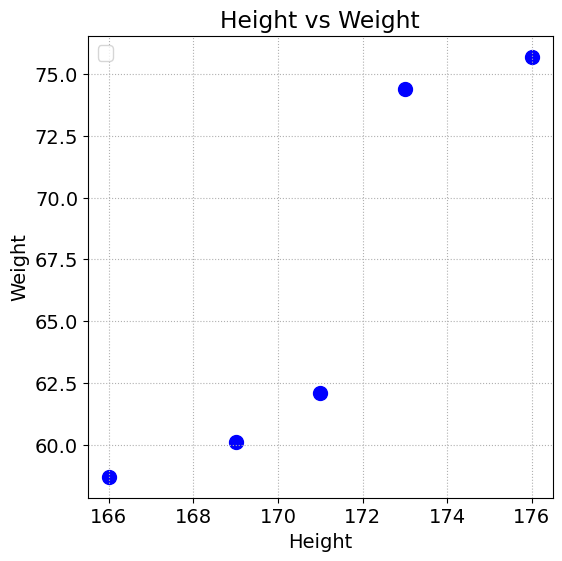

In [ ]:
plt.scatter(x,y,c='b',s=100)
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

<ipython-input-22-7af22deba9f1>:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


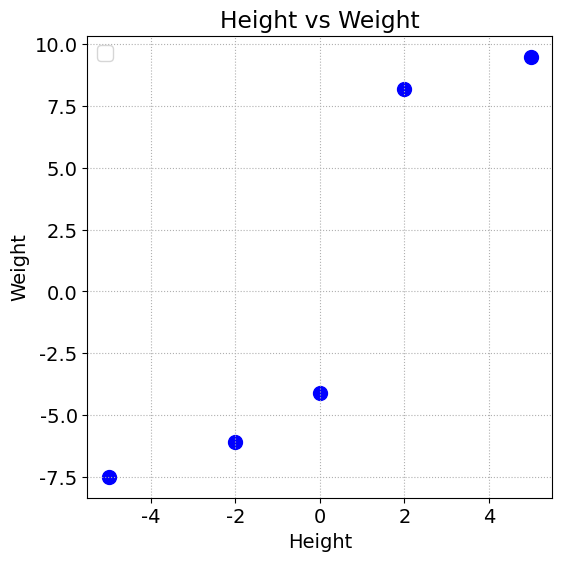

In [ ]:
X=x-x.mean()
Y=y-y.mean()

plt.scatter(X,Y,c='b',s=100)
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

In [ ]:
##
X=torch.tensor(X).float()
Y=torch.tensor(Y).float()

print(X)
print(Y)

tensor([-2.7500, -0.7500,  0.2500,  3.2500])
tensor([-0.4884, -0.4877, -0.4869, -0.4861, -0.4851, -0.4841, -0.4829, -0.4817,
        -0.4803, -0.4788, -0.4771, -0.4752, -0.4732, -0.4709, -0.4685, -0.4658,
        -0.4628, -0.4595, -0.4559, -0.4520, -0.4476, -0.4429, -0.4377, -0.4321,
        -0.4259, -0.4192, -0.4119, -0.4039, -0.3953, -0.3860, -0.3759, -0.3650,
        -0.3532, -0.3406, -0.3271, -0.3126, -0.2973, -0.2809, -0.2636, -0.2453,
        -0.2261, -0.2060, -0.1850, -0.1633, -0.1407, -0.1175, -0.0938, -0.0695,
        -0.0449, -0.0200,  0.0049,  0.0299,  0.0548,  0.0794,  0.1036,  0.1274,
         0.1506,  0.1731,  0.1949,  0.2159,  0.2360,  0.2552,  0.2735,  0.2908,
         0.3071,  0.3225,  0.3370,  0.3505,  0.3631,  0.3748,  0.3857,  0.3958,
         0.4052,  0.4138,  0.4218,  0.4291,  0.4358,  0.4420,  0.4476,  0.4528,
         0.4575,  0.4618,  0.4658,  0.4694,  0.4726,  0.4756,  0.4783,  0.4808,
         0.4831,  0.4851,  0.4869,  0.4886,  0.4902,  0.4915,  0.4928,  0.4

In [ ]:
##parameters init Y=B+WX
W=torch.tensor(1.0, requires_grad=True)
B=torch.tensor(1.0, requires_grad=True)

print(W)
print(B)

tensor(1., requires_grad=True)
tensor(1., requires_grad=True)


In [ ]:
##
def pred(X):
  return W*X +B


def mse(Yp,Y):
  loss=((Yp-Y)**2).mean()
  return loss

In [ ]:
##학습
#
Yp=pred(X)
print('pred=',Yp)

loss=mse(Yp,Y)#예측값, 실측값
print('loss=',loss)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [ ]:
from torchviz import make_dot
import torch

In [ ]:
g=make_dot(loss,params={'W':W,'B':B})
# loss를 기준으로 컴퓨테이션 그래프 를 생성.
# params={'W': W, 'B': B}: W와 B도 연산 과정에서 어떤 역할을 하는지 그래프에 표시.
display(g)

In [ ]:
##
print(W.grad)
print(B.grad)

loss.backward()

print(W.grad)
print(B.grad)

In [ ]:
##learning,update
lr=0.001

with torch.no_grad():
  W=W-lr*W.grad
  B=B-lr*B.grad


  W.grad.zero_()
  B.grad.zero_()

In [ ]:
print(W.grad)
print(B.grad)

print('W=',W)
print('B=',B)

In [ ]:
##For loop
W=torch.tensor(1.0, requires_grad=True).float()
B=torch.tensor(1.0, requires_grad=True).float()

num_epochs=500
lr=0.001

##loss history (점점떨어짐)
history=np.zeros((0,2)) #row=0,column=2
print('history=',history)


In [ ]:
Yp=pred(X)
print('pred=',Yp)

loss=mse(Yp,Y)#예측값, 실측값
print('loss=',loss)

In [ ]:
W=torch.tensor(1.0, requires_grad=True)
B=torch.tensor(1.0, requires_grad=True)

print(W)
print(B)

In [ ]:
##학습
for epoch in range(num_epochs):
  # print('epoch=',epoch)

  ##pred(에측)
  Yp=pred(X)

  ##loss
  loss=mse(Yp,Y) #tensor type
  loss.backward()
  #optim
  with torch.no_grad():
    W-=lr*W.grad
    B-=lr*B.grad

    ##grad 초기화
    W.grad.zero_()
    B.grad.zero_()
  if epoch %10==0:
    item=np.array([epoch,loss.item()])
    history=np.vstack([history,item])
    print(f'epoch={epoch},loss={loss.item():.4f}')

In [ ]:
print('W=',W)
print('B=',B)

In [ ]:
# print(history)
plt.plot(history[:,0],history[:,1]) #epoch 와 loss 를 지정
plt.title('learning curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


In [ ]:
##
print(W.item())
print(B.item())

W_numpy=W.item()
B_numpy=B.item()


In [ ]:
Yp

In [ ]:
## Y=W*X+B
plt.scatter(X,Y,c='k',s=100)
plt.plot([-5,5],[W_numpy*-5+B_numpy,W_numpy*5+B_numpy])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [ ]:
##
W=torch.tensor(1.0,requires_grad=True).float()
B=torch.tensor(1.0,requires_grad=True).float()

num_epochs=500

lr=0.001




In [ ]:
from torch import optim
optimizer=optim.SGD([W,B],lr=lr)#학습할거 대입

NameError: name 'lr' is not defined

In [ ]:
history=np.zeros((0,2))

for epoch in range(num_epochs):

  Yp=pred(X)

  loss=mse(Yp,Y)

  optimizer.zero_grad() #초기화
  loss.backward()

  optimizer.step()#with no grad 부분 대신

  if epoch %10 ==0:
    item=np.array([epoch,loss.item()])
    history=np.vstack([history,item])
    #np.vstack([history, item])를 사용하면 기존 history 배열 아래에 item을 추가
    print(f'Epoch={epoch},Loss={loss.item():.4f}')

In [ ]:
print('W=',W.item())
print('B=',B.item())

plt.plot(history[:,0],history[:,1],c='r')
plt.title("Epoch VS Loss")
plt.xlabel('Epoch')
plt.ylabel("Loss")
plt.show()

6강 오후강의

In [ ]:
##선형회귀 손실함수
def linear(x,w,b=0):
  y=torch.matmul(x,w)+b
  return y

In [ ]:
x=torch.tensor([[1,2,3],
                [2,4,6]]).float()
print(x)

print('initial value=','='*50)

#hidden1
w1=torch.rand(3,4)
b1=torch.rand(1,4)

#hidden2
w2=torch.rand(4,3)
b2=torch.rand(1,3)

print('w1=\n',w1)
print('b1=\n',b1)

print('w2=\n',w2)
print('b2=\n',b2)

In [ ]:
##Hidden  node=4
print('Hidden layer1=')
h1=linear(x,w1,b1)
print(h1)
##Hidden node=3
h2=linear(h1,w2,b2)
print('Hidden layer 2 =')
print(h2)

In [ ]:
##single data 회귀분석->MSE loss output layer activation=Linear
from torch import nn,optim



input=torch.randn(1,requires_grad=True) #이거는 학습
target=torch.randn(1)

print('Before SGD:')

print('input:',input)
print('target:',target)

##MSE loss class
lr=0.01
loss=nn.MSELoss()
optimizer=optim.SGD([input],lr=lr)

num_epochs=100
loss_history=[]

##learning
for epoch in range(num_epochs):
  ##pred
  pred=input
  cost=loss(pred,target)#항상 앞쪽에 pred 뒤에는 target

  optimizer.zero_grad()
  cost.backward()
  optimizer.step() #update

  loss_history.append(cost.item())
  if epoch%10==0:
    print(f'epoch={epoch},cost={cost.item():.4f}')


print('After SGD:')
print('input:',input)
print('target:',target)

Before SGD:
input: tensor([0.6559], requires_grad=True)
target: tensor([-1.2419])
epoch=0,cost=3.6017
epoch=10,cost=2.4045
epoch=20,cost=1.6053
epoch=30,cost=1.0717
epoch=40,cost=0.7155
epoch=50,cost=0.4777
epoch=60,cost=0.3189
epoch=70,cost=0.2129
epoch=80,cost=0.1421
epoch=90,cost=0.0949
After SGD:
input: tensor([-0.9902], requires_grad=True)
target: tensor([-1.2419])


In [ ]:
##Linear
l1=nn.Linear(784,128) #input, output
l2=nn.Linear(128,10)#최종 출력이 10인 이유는 보통 MNIST 같은 숫자 분류(0~9) 작업을 수행하기 때문입니다
relu=nn.ReLU(inplace=True)

# 첫 번째 레이어 l1은 입력 데이터를 적절한 크기의 특징 벡터로 변환.
# 두 번째 레이어 l2는 변환된 특징을 최종 출력 차원(10개 클래스)으로 변환.
# 중간에 ReLU 활성화 함수를 넣어 비선형성을 추가하여 모델의 표현력을 향상.

print('l1 weights=\n',l1.weight)
print('l1 weights=\n',l1.weight.shape)


In [ ]:
##input data
inputs=torch.randn(100,784)#randn 표준이 0이고 분산이 1인 정규분포
print('inputs=\n',inputs) #100행 784열  이데이터를 l1과 l2를 통과시킬 예정

In [ ]:
###hidden의ㅣ output
m1=l1(inputs)
print('m1=\n',m1)
print('m1=\n',m1.shape) # (100, 784) × (784, 128) → (100, 128)

Youtube07강 강의

In [ ]:
sampleData1=np.array(
    [[166, 58.7],
    [176, 75.7],
    [171, 62.1],
    [173,74.4],
    [169,60.1]])

print('sampleData1=\n',sampleData1)

x=sampleData1[:,0]#height #166,176,171,173,169
y=sampleData1[:,1]#weight #58.7,75.7,62.1,74.4,60.1

X=x-x.mean()#centering
Y=y-y.mean()

In [ ]:
plt.scatter(X,Y,c='b',s=100,alpha=0.6)
plt.show()

In [ ]:
import torch
from torch import nn, optim

In [ ]:
##
X=torch.tensor(x,requires_grad=True).float()
Y=torch.tensor(y,requires_grad=True).float()

print(X.dtype)
print(Y.dtype)

In [ ]:
##Parameter init
W=torch.tensor(1.0, requires_grad=True)
B=torch.tensor(1.0, requires_grad=True)

#예측
def pred(X):
  y=W*X+B
  return y

##손실함수
def mse(Yp,Y): #Yp(예측값)과 Y(정답값)을 입력 손실함수에는
  y=((Yp-Y)**2).mean()
  return y
#손실 함수는 모델의 예측(Yp)과 실제 정답(Y) 간의 차이를 계산해서,
# 이 값이 작을수록 모델이 더 정확하게 예측하고 있음을 의미


##학습 파라메터=hyperparameter
num_epochs=500
lr=0.001



In [ ]:
##학습 시작
history=np.zeros((0,2))
# print(history) # 공간확인

for epoch in range(num_epochs):
  ##prediction
  Yp=pred(X)

  ##MSE loss
  loss=mse(Yp,Y)
  ##gradient
  loss.backward()

  with torch.no_grad():
    W-=lr*W.grad
    B-=lr*B.grad

    W.grad.zero_()
    B.grad.zero_()

  if epoch %10 ==0:
    item=np.array([epoch,loss.item()])
    history=np.vstack([history,item])
    print(f'epoch={epoch},loss={loss.item():.4f}')

In [ ]:
plt.plot(history[:,0],history[:,1])
plt.show()

In [ ]:
W=torch.tensor(1.0, requires_grad=True)
B=torch.tensor(1.0, requires_grad=True)

#예측
def pred(X):
  y=W*X+B
  return y

##손실함수
# def mse(Yp,Y):
#   y=((Yp-Y)**2).mean()
#   return y
lr=0.001
loss=nn.MSELoss()
optimizer=optim.SGD([W,B],lr=lr)

##학습 파라메터=hyperparameter
num_epochs=500


In [ ]:
for epoch in range(num_epochs):
  ##prediction
  Yp=pred(X)

  ##MSE loss
  # loss=mse(Yp,Y)
  cost=loss(Yp,Y) #예측값과 실측값
  ##gradient
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()
  # with torch.no_grad():
  #   W-=lr*W.grad
  #   B-=lr*B.grad

  #   W.grad.zero_()
  #   B.grad.zero_()

  if epoch %10 ==0:
    item=np.array([epoch,cost.item()])
    history=np.vstack([history,item])
    print(f'epoch={epoch},loss={cost.item():.4f}')

In [ ]:
##
l1=nn.Linear(784,128)
l2=nn.Linear(128,10)
relu=nn.ReLU(inplace=True)
# print(list(l1.parameters()))
#parameters()는객체의 학습 가능한
#가중치(weight)와 편향(bias)를 반환하는 메서드

# print(l1.weight.shape)
# print(l1.bias.shape)

In [ ]:
inputs=torch.randn((100,784))
# print(inputs)

h1=l1(inputs)
print(h1.shape)

여기서부터는 BCE를 해보쟈!


In [ ]:
import torch
from torch import nn, optim

In [ ]:
##
l1=nn.Linear(784,128)
l2=nn.Linear(128,10)
relu=nn.ReLU(inplace=True)

In [ ]:
##
np.random.seed(226)
x=np.random.randn(100,1)
# print(x)
y=x**2 +np.random.randn(100,1) #np.부터는 noise추가

######## Train set, Test set deep learning 할때 나눠서 쓴다
x_train=x[:50]
x_test=x[50:]

y_train=y[:50]
y_test=y[50:]
# print(x_train.shape)
# print(x_test.shape)

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(x_train,y_train,c='b', label='Training set')
plt.scatter(x_test,y_test,c='k',marker='x',label='Test set')
plt.legend()
plt.show()

In [ ]:
##
#activation 함수 렐루가 없다면?
#training set
inputs=torch.tensor(x_train).float()
labels=torch.tensor(y_train).float() #target

##test set
inputs_test=torch.tensor(x_test).float()
labels_test=torch.tensor(y_test).float()

In [ ]:
##
#Class로 묶어서 사용하기
l1=nn.Linear(1, 3)
l2=nn.Linear(3, 1)
relu=nn.ReLU(inplace=True)
h1=l1(inputs)
pred=l2(h1)
print(pred)

In [ ]:
##model class
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1=nn.Linear(1,1)


  def forward(self,x):#__call__
    x1=self.l1(x)

    return x1




In [ ]:
#omdel for prediction
net=Net()

#hyperparameters
lr=0.001
#loss function
criterion = nn.MSELoss()
#optimizer
optimizer=optim.SGD(net.parameters(),lr=lr)

##
num_epochs=10000

history=np.zeros((0,2))

In [ ]:
#training process
for epoch in range(num_epochs):
  ##pred
  outputs=net(inputs)

  ##loss
  loss=criterion(outputs, labels)

  #초기화
  optimizer.zero_grad()

  #gradient
  loss.backward()

  #update
  optimizer.step()

  if epoch % 100 ==0:
    item=np.array([epoch, loss.item()])
    history=np.vstack([history,item])
    print(f'Epoch={epoch},Loss={loss.item():4f}')





In [ ]:
plt.plot(history[:,0],history[:,1])
plt.title("Epoch vs MSE")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
##test
labels_pred=net(inputs_test)

plt.scatter(inputs_test[:,0].data,labels_pred[:,0].data,c='b',label='prediction')
plt.scatter(inputs_test[:,0].data,labels_test[:,0].data,c='k',marker='x',label='true')
plt.legend()
plt.show()

In [ ]:
class Net2(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1=nn.Linear(1,10)
    self.l2=nn.Linear(10,10)
    self.l3=nn.Linear(10,1)


  def forward(self,x):
    x1=self.l1(x)
    x2=self.l2(x1)
    x3=self.l3(x2)

    return x3

In [ ]:
net2=Net2()

#hyperparameter
lr=0.001

criterion=nn.MSELoss()
optimizer=optim.SGD(net2.parameters(),lr=lr)

num_epochs=10000
history=np.zeros((0,2))

In [ ]:
##training

for epoch in range(num_epochs):
  outputs = net2(inputs)

  loss=criterion(outputs,labels)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 ==0:
    item=np.array([epoch, loss.item()])
    history=np.vstack([history,item])
    print(f'Epoch={epoch},Loss={loss.item():4f}')




In [ ]:
##test
labels_pred=net2(inputs_test)

plt.scatter(inputs_test[:,0].data,labels_pred[:,0].data,c='b',label='prediction')
plt.scatter(inputs_test[:,0].data,labels_test[:,0].data,c='k',marker='x',label='true')
plt.legend()
plt.show()

#Linear함수로만 구성되어 있어 구체적으로 확인 불가하다

In [ ]:
##
class Net3(nn.Module):
  def __init__(self):
    super().__init__()
    self.l1=nn.Linear(1,10)# 입력 1 → 은닉층 10
    self.l2=nn.Linear(10,10)# 은닉층 10 → 은닉층 10
    self.l3=nn.Linear(10,1)# 은닉층 10 → 출력 1


    self.relu=nn.ReLU(inplace=True)

  def forward(self,x):
    x1=self.l1(x)
    x1=self.relu(x1)#활성화 함수를 레이어층에 대입
    x2=self.l2(x1)
    x2=self.relu(x2)
    x3=self.l3(x2)


    return x3



In [ ]:
net3=Net3()

##hyperparmeter
lr=0.001

criterion=nn.MSELoss()
optimizer=optim.SGD(net3.parameters(),lr=lr)

num_epochs=10000
history=np.zeros((0,2))


In [ ]:
##Training
for epoch in range(num_epochs):
  outputs = net3(inputs)

  loss=criterion(outputs,labels)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


  if epoch % 100 ==0:
    item=np.array([epoch, loss.item()])
    history=np.vstack([history,item])
    print(f'Epoch={epoch},Loss={loss.item():4f}')




In [ ]:
##test
labels_pred=net3(inputs_test)

plt.scatter(inputs_test[:,0].data,labels_pred[:,0].data,c='b',label='prediction')
plt.scatter(inputs_test[:,0].data,labels_test[:,0].data,c='k',marker='x',label='true')
plt.legend()
plt.show()

여기부터는 Youtube 07강
강의 오후

In [ ]:
##Binary classification/cost function
## output layer 활성함수 Sigmoid

def sigmoid(x,w=1):
  return 1/(1+np.exp(-w*x))

x=np.arange(-5,5,0.1)
# print('x=\n',x)
y=sigmoid(x)
y1=sigmoid(x,w=2)
y2=sigmoid(x,w=0.5)

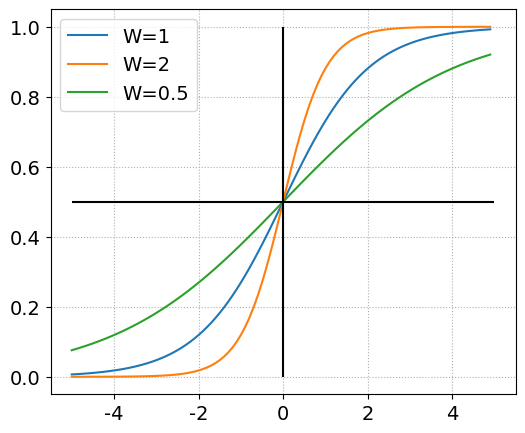

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(x,y,label='W=1')
plt.plot(x,y1,label='W=2')
plt.plot(x,y2,label='W=0.5')
plt.legend()
plt.hlines(0.5,-5,5,color='k')
plt.vlines(0,0,1,color='k')
plt.show()

In [ ]:
##sigmoid, Loss=BCE
x_data=[[1,2],
        [2,3],
        [3,1],
        [4,3],
        [5,3],
        [6,2]]
y_data=[[0],[0],[0],[1],[1],[1]]

display(x_data)
display(y_data)

[[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]

[[0], [0], [0], [1], [1], [1]]

In [ ]:
import torch

In [ ]:
x_train=torch.tensor(x_data).float()
y_train=torch.tensor(y_data).float()#torch.FloatTensor(y_data)동일한 코드

print('x_train shpae=',x_train.shape)
print('y_train shape=',y_train.shape)

x_train shpae= torch.Size([6, 2])
y_train shape= torch.Size([6, 1])


In [ ]:
##paramter init
W=torch.zeros((2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

print('W=',W)
print('B=',B)

#sigmoid 정의
def prob(x,w,b):
  y=1/(1+torch.exp(-(torch.matmul(x,w)+b)))
  return y

In [ ]:
##prediction
pred=prob(x_train,W,b)
print('pred=',pred)##nn.Sigmoid()

#cost function
losses=-(y_train*torch.log(pred)+((1-y_train)*torch.log(1-pred)))
cost=losses.mean() ##nn.BCELoss()

print('cost=',cost)

In [ ]:
##메뉴얼이 아닌 자동으로 실행하는법
x_train=torch.tensor(x_data).float()
y_train=torch.tensor(y_data).float()


print('x_train shpae=',x_train)
print('y_train shape=',y_train)

#parammeter init
W=torch.zeros((2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)


sigmoid=nn.Sigmoid() #sigmoid
loss=nn.BCELoss() #BCE
optimizer=optim.SGD([W,b],lr=lr)


x_train shpae= tensor([[1., 2.],
        [2., 3.],
        [3., 1.],
        [4., 3.],
        [5., 3.],
        [6., 2.]])
y_train shape= tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])


In [ ]:
##learning
num_epochs=1000
history=np.zeros((0,2))

for epoch in range(num_epochs):

  pred=sigmoid(torch.matmul(x_train,W)+b)#probability
  cost=loss(pred,y_train)

  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch %100==0:
    print('Epoch={}, Cost={:.4f}'.format(epoch, cost.item()))
    history=np.vstack([history,np.array([epoch,cost.item()])])


Epoch=0, Cost=0.6931
Epoch=100, Cost=0.5781
Epoch=200, Cost=0.5352
Epoch=300, Cost=0.5056
Epoch=400, Cost=0.4840
Epoch=500, Cost=0.4673
Epoch=600, Cost=0.4537
Epoch=700, Cost=0.4421
Epoch=800, Cost=0.4320
Epoch=900, Cost=0.4229


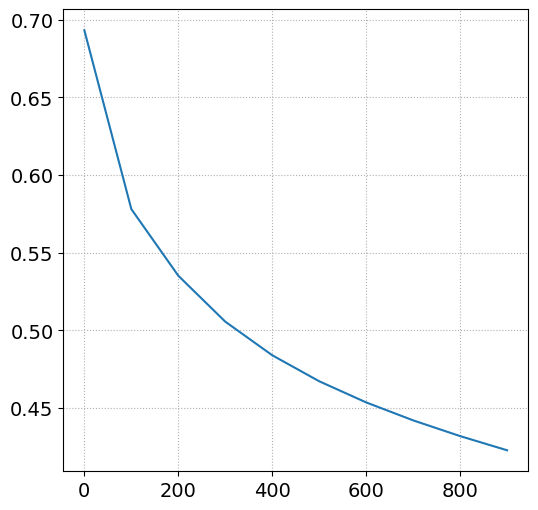

In [ ]:
plt.plot(history[:,0],history[:,1])
plt.show()

In [ ]:
##multinomial classification, 다중분류
##출력층 활성화 함수 = Softmax
##Loss function= cross entropy, one-hot encoding

In [ ]:
def softmax(x):
  y=np.exp(x)/np.sum(np.exp())
  return y

x=np.array([1,3,4,7])
print(softmax(x))

TypeError: exp() takes from 1 to 2 positional arguments but 0 were given

In [ ]:
y=torch.tensor([])

In [ ]:
x=torch.rand(3,5,requries_grad=True) #0~1
print('x=\n',x)

nn.softmax=nn.Softmax()
prob=nn_softmax(x)

##one-hot encoding
y_one_hot=torch.zeros_like(x)
print('y_one_hot=\n',y_one_hot)

y_one_hot.scatter_(dim=1,index=y.unszueeze(dim=1),value=1)
print('y_one_hot=\n',y_one_hot)



TypeError: rand() received an invalid combination of arguments - got (int, int, requries_grad=bool), but expected one of:
 * (tuple of ints size, *, torch.Generator generator, tuple of names names, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, torch.Generator generator, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, tuple of names names, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [ ]:
(y_one_hot*torch.log(prob)).sum(dim=1).mean()

In [ ]:
##multinomoal classification

x_train=[[1,2,1,1],
         [2,1,3,2],
         [3,1,3,4],
         [4,1,5,5],
         [1,7,5,5],
         [1,2,5,6],
         [1,6,6,6],
         [1,7,7,7]]
y_train=[2,2,2,1,1,1,0,0]
x_train=torch.tensor(x_train).float()
y_train=torch.tensor(y_train).long()

print('x_train shape=',x_train.shape)
print('y_train shape=',y_train.shape)

#
y_one_hot=torch.zeros(8,3)
print(y_one_hot)
y_one_hot.scatter_(1,y_train.unsqueeze(1),1)
print(y_one_hot) # 인덱스 자리에 1이 들어감

W=torch.zeros((4,3),requires_grad=True)
b=torch.zeros((1,3),requries_grad=True)

lr=0.1
optimizer=optim.SGD([W,b],lr=lr)
nn_softmax=nn.Softmax()

##learning
num_epochs=100
history_loss=[]


x_train shape= torch.Size([8, 4])
y_train shape= torch.Size([8])
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
tensor([[0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.]])


TypeError: zeros() received an invalid combination of arguments - got (tuple, requries_grad=bool), but expected one of:
 * (tuple of ints size, *, tuple of names names, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [ ]:
for epoch in range(num_epochs):
  prob=nn_softmax(torch.matmul(x_train,W)+b)
  cost=-(y_one_hot*torch.log(prob)).sum(dim=1).mean()


  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  if epoch %10==0:
    history_loss.append(cost.item())
    print(f'Epoch={epoch},Loss={cost.item()}')

NameError: name 'nn_softmax' is not defined